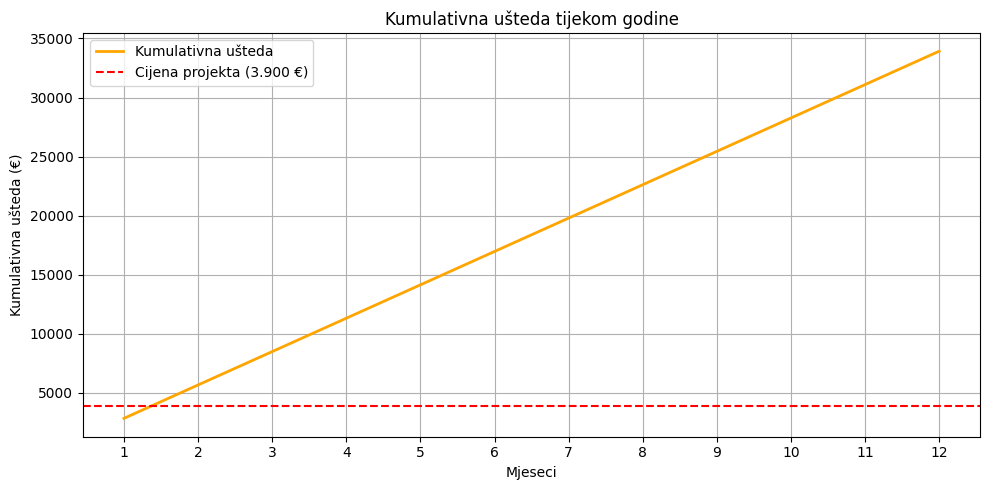

Satnica: 7.71 €/sat
Dnevna ušteda vremena: 16.67 sati
Mjesečna ušteda (samo vrijeme): 2827.08 €
Mjesečna ušteda (smanjenje grešaka): 212.03 €
Ukupna mjesečna ušteda: 3039.11 €
Povrat investicije (samo vrijeme): 1.38 mjeseci
Povrat investicije (ukupno): 1.28 mjeseci


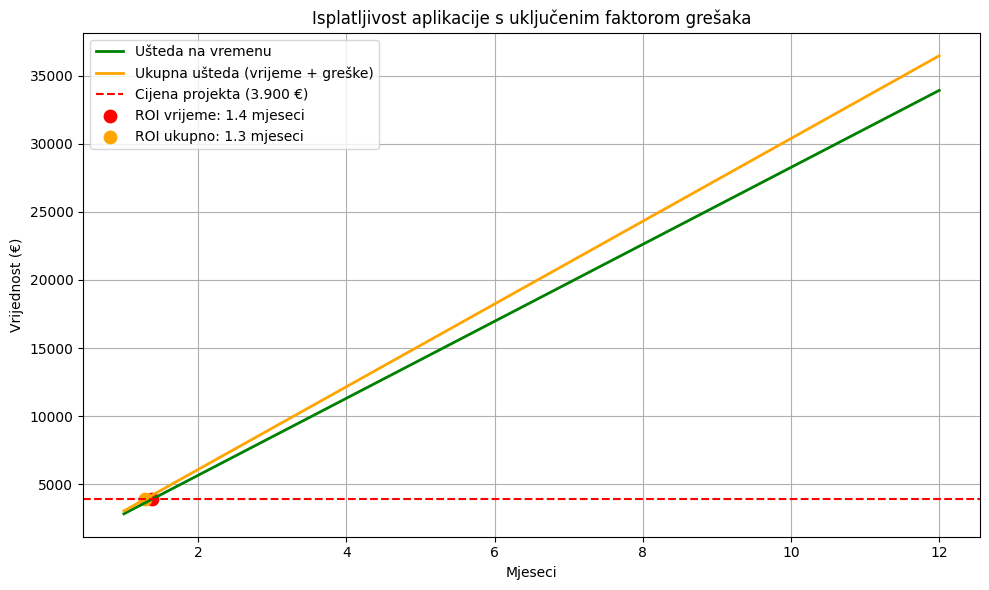

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Osnovni parametri prema novim podacima
monthly_salary = 1357  # Mjesečna plaća u € za 2025.
working_hours_per_month = 176  # 8 sati dnevno * 22 radna dana
hourly_wage = monthly_salary / working_hours_per_month  # Satnica (7,71 €/sat)
contracts_per_day = 100  # Broj ugovora dnevno
time_saved_per_contract = 10  # Minuta ušteđeno po ugovoru (ažurirano na 10 min)
working_days_per_month = 22  # Radni dani u mjesecu
project_cost = 3900  # Cijena projekta u €
months = range(1, 13)  # 12 mjeseci

# Izračun uštede vremena
daily_time_saved_hours = (contracts_per_day * time_saved_per_contract) / 60  # Pretvaranje minuta u sate (16,67 sati)
daily_savings = daily_time_saved_hours * hourly_wage  # Ušteđeno dnevno u €
monthly_savings = daily_savings * working_days_per_month  # Ušteđeno mjesečno (~2.829 €)
cumulative_savings = [monthly_savings * m for m in months]  # Kumulativna ušteda po mjesecima

# 1. Graf: Kumulativna ušteda vremena
plt.figure(figsize=(10, 5))
plt.plot(months, cumulative_savings, label="Kumulativna ušteda", color="orange", linewidth=2)
plt.axhline(y=project_cost, color="red", linestyle="--", label="Cijena projekta (3.900 €)")
plt.xlabel("Mjeseci")
plt.ylabel("Kumulativna ušteda (€)")
plt.title("Kumulativna ušteda tijekom godine")
plt.grid(True)
plt.xticks(months)
plt.legend()
plt.tight_layout()
plt.show()

# Ažurirane vrijednosti za faktore greške
hourly_wage_updated = hourly_wage
time_saved_per_contract_updated = time_saved_per_contract
daily_time_saved_hours_updated = daily_time_saved_hours
daily_savings_updated = daily_savings
monthly_savings_updated = monthly_savings
cumulative_savings_updated = cumulative_savings

# Dodavanje faktora greške
error_minutes = 15  # Vrijeme potrebno za ispravljanje greške (min)
error_value_per_error = (error_minutes / 60) * hourly_wage_updated  # Trošak po jednoj grešci u €
errors_per_day = 100 * 0.05  # 5% ugovora imaju grešku (5 grešaka dnevno)
monthly_error_savings = errors_per_day * error_value_per_error * working_days_per_month  # Mjesečna ušteda od smanjenja grešaka

# Ukupna mjesečna ušteda (vrijeme + greške)
total_monthly_savings = monthly_savings_updated + monthly_error_savings
total_cumulative_savings = [total_monthly_savings * m for m in months]

# Točka povrata investicije (ROI)
roi_time = np.interp(project_cost, cumulative_savings_updated, months)
roi_total = np.interp(project_cost, total_cumulative_savings, months)

# 2. Graf: Kumulativna ušteda + doprinos smanjenja grešaka
plt.figure(figsize=(10, 6))
plt.plot(months, cumulative_savings_updated, label="Ušteda na vremenu", color="green", linewidth=2)
plt.plot(months, total_cumulative_savings, label="Ukupna ušteda (vrijeme + greške)", color="orange", linewidth=2)
plt.axhline(y=project_cost, color="red", linestyle="--", label="Cijena projekta (3.900 €)")
plt.scatter(roi_time, project_cost, color='red', marker='o', s=80, label=f"ROI vrijeme: {roi_time:.1f} mjeseci")
plt.scatter(roi_total, project_cost, color='orange', marker='o', s=80, label=f"ROI ukupno: {roi_total:.1f} mjeseci")
plt.xlabel("Mjeseci")
plt.ylabel("Vrijednost (€)")
plt.title("Isplatljivost aplikacije s uključenim faktorom grešaka")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Ispis finansijskih pokazatelja
print(f"Satnica: {hourly_wage:.2f} €/sat")
print(f"Dnevna ušteda vremena: {daily_time_saved_hours:.2f} sati")
print(f"Mjesečna ušteda (samo vrijeme): {monthly_savings_updated:.2f} €")
print(f"Mjesečna ušteda (smanjenje grešaka): {monthly_error_savings:.2f} €")
print(f"Ukupna mjesečna ušteda: {total_monthly_savings:.2f} €")
print(f"Povrat investicije (samo vrijeme): {roi_time:.2f} mjeseci")
print(f"Povrat investicije (ukupno): {roi_total:.2f} mjeseci")

plt.show()